In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
dataset_file_path = '../dataset/Gross Profit vs Competitor 0514.xlsx'

df_raw = pd.read_excel(dataset_file_path)

def clean_col(c):
    return (str(c).strip()
            .replace(' ', '_')
            .replace('(', '')
            .replace(')', '')
            .replace(':', '')
            .replace(',', '')
            .replace('/', '_')
            .lower())

df = df_raw.copy()
df.columns = [clean_col(c) for c in df.columns]

# Rename the long outcome column to a simpler name, but do NOT change its label values.
rename_map = {
    'convert_to_order_0success_1fail': 'convert_to_order',
    'gross_margin_rate': 'gross_margin_rate',
}
df = df.rename(columns=rename_map)

if df is not None:
    print(f"File {dataset_file_path} loaded successfully.")
    print("Cleaned columns:")
    print(df.columns.tolist())
else:
    print(f"Failed to load file {dataset_file_path}.")

df.head()


File ../dataset/Gross Profit vs Competitor 0514.xlsx loaded successfully.
Cleaned columns:
['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate', 'convert_to_order', 'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c']


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
0,Q-00114,W,11.0000,"136,000.0000",1,"136,000.0000",0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3079,0,222000,"360,000.0000",NaN,NaN
2,Q-00161,Y,150.0000,"2,379,000.0000",1,"2,379,000.0000",0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0000,"300,000.0000",1,"300,000.0000",0.6787,0,132000,"240,000.0000",NaN,NaN
4,Q-00517,I1,22.0000,"228,964.0000",1,"228,964.0000",0.2949,0,132000,"240,000.0000",NaN,NaN


In [3]:
df

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
0,Q-00114,W,11.0000,"136,000.0000",1,"136,000.0000",0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3079,0,222000,"360,000.0000",NaN,NaN
2,Q-00161,Y,150.0000,"2,379,000.0000",1,"2,379,000.0000",0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0000,"300,000.0000",1,"300,000.0000",0.6787,0,132000,"240,000.0000",NaN,NaN
4,Q-00517,I1,22.0000,"228,964.0000",1,"228,964.0000",0.2949,0,132000,"240,000.0000",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4989,Q-44379,H1,37.0000,"355,752.0000",1,"355,752.0000",0.3879,0,222000,"360,000.0000",NaN,NaN
4990,Q-42582,X,11.0000,"203,000.0000",1,"203,000.0000",0.5103,1,66000,NaN,NaN,NaN
4991,Q-45260,X,11.0000,"123,911.2000",1,"123,911.2000",0.1931,0,66000,NaN,NaN,NaN
4992,Q-22566,O1,75.0000,"626,400.0000",1,"626,400.0000",0.2627,0,375000,"760,000.0000","900,000.0000",NaN


# General

In [4]:
print(f"Number of columns/features: {df.shape[1]}")
print(f"Number of rows/data: {df.shape[0]}")

print()
print("List of columns:", df.columns)

Number of columns/features: 12
Number of rows/data: 4994

List of columns: Index(['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price',
       'gross_margin_rate', 'convert_to_order', 'energy_grant_amount',
       'competitor_a', 'competitor_b', 'competitor_c'],
      dtype='object')


In [5]:
df.head()

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
0,Q-00114,W,11.0000,"136,000.0000",1,"136,000.0000",0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3079,0,222000,"360,000.0000",NaN,NaN
2,Q-00161,Y,150.0000,"2,379,000.0000",1,"2,379,000.0000",0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0000,"300,000.0000",1,"300,000.0000",0.6787,0,132000,"240,000.0000",NaN,NaN
4,Q-00517,I1,22.0000,"228,964.0000",1,"228,964.0000",0.2949,0,132000,"240,000.0000",NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quote_id             4994 non-null   object 
 1   product              4994 non-null   object 
 2   kw                   4994 non-null   float64
 3   unit_price           4994 non-null   float64
 4   qty                  4994 non-null   int64  
 5   subtotal_price       4994 non-null   float64
 6   gross_margin_rate    4994 non-null   float64
 7   convert_to_order     4994 non-null   int64  
 8   energy_grant_amount  4994 non-null   int64  
 9   competitor_a         4106 non-null   float64
 10  competitor_b         466 non-null    float64
 11  competitor_c         57 non-null     float64
dtypes: float64(7), int64(3), object(2)
memory usage: 468.3+ KB


In [7]:
# Treat convert_to_order as a categorical outcome.
# IMPORTANT: do not change the label values.
# 0 = Success, 1 = Fail
df['convert_to_order'] = df['convert_to_order'].astype('object')

print(df['convert_to_order'].dtype)
print(df['convert_to_order'].value_counts(dropna=False))


object
convert_to_order
1    3727
0    1267
Name: count, dtype: int64


In [8]:
df.dtypes

quote_id                object
product                 object
kw                     float64
unit_price             float64
qty                      int64
subtotal_price         float64
gross_margin_rate      float64
convert_to_order        object
energy_grant_amount      int64
competitor_a           float64
competitor_b           float64
competitor_c           float64
dtype: object

In [9]:
df.describe()

,kw,unit_price,qty,subtotal_price,gross_margin_rate,energy_grant_amount,competitor_a,competitor_b,competitor_c
count,"4,994.0000","4,994.0000","4,994.0000","4,994.0000","4,994.0000","4,994.0000","4,106.0000",466.0000,57.0000
mean,33.7344,"432,367.5778",1.1904,"502,238.2438",0.3741,"182,776.2835","358,315.0268","900,000.0000","2,008,771.9298"
std,30.5795,"466,225.2342",0.8403,"612,255.7064",0.1759,"140,905.9578","281,846.2700",0.0000,"28,540.0831"
min,7.5000,"40,200.0000",0.0000,0.0000,-1.3226,"38,700.0000","10,500.0000","900,000.0000","2,000,000.0000"
25%,15.0000,"226,395.0000",1.0000,"240,000.0000",0.2514,"90,000.0000","240,000.0000","900,000.0000","2,000,000.0000"
50%,22.0000,"284,076.0000",1.0000,"345,935.5200",0.3979,"132,000.0000","240,000.0000","900,000.0000","2,000,000.0000"
75%,37.0000,"421,200.0000",1.0000,"555,000.9000",0.4709,"222,000.0000","360,000.0000","900,000.0000","2,000,000.0000"
max,200.0000,"4,600,000.0000",16.0000,"10,443,200.0000",0.9211,"960,000.0000","1,880,000.0000","900,000.0000","2,100,000.0000"


In [10]:
df.describe(include="object")

,quote_id,product,convert_to_order
count,4994,4994,4994
unique,4640,43,2
top,Q-26060,I1,1
freq,12,1532,3727


In [11]:
df.isna().sum()

# it seems to be difficult to get the price from competitor
# Q: is it depends on the competitor company, difficult to easier: A -> B -> C

quote_id                  0
product                   0
kw                        0
unit_price                0
qty                       0
subtotal_price            0
gross_margin_rate         0
convert_to_order          0
energy_grant_amount       0
competitor_a            888
competitor_b           4528
competitor_c           4937
dtype: int64

In [12]:
# check columns that only have 1 unique value
single_unique_cols = df.columns[df.nunique(dropna=True) == 1]

print("Columns with only 1 unique value:")
print(single_unique_cols.tolist())
print("Total column:", len(single_unique_cols))

Columns with only 1 unique value:
['competitor_b']
Total column: 1


## Duplicate unique ID

In [13]:
# check duplicate rows
duplicate_count = df.duplicated().sum()
print("Total duplicated rows:", duplicate_count)

# show all duplicated rows
duplicated_rows_all = df[df.duplicated(keep=False)]
print("Duplicated rows preview:")
display(duplicated_rows_all.head())

Total duplicated rows: 89
Duplicated rows preview:


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
20,Q-02113,N1,75.0000,"718,000.0000",2,"1,436,000.0000",0.3393,0,375000,"760,000.0000","900,000.0000",NaN
33,Q-03409,N1,75.0000,"1,283,500.0000",1,"1,283,500.0000",0.6487,1,375000,"760,000.0000","900,000.0000",NaN
34,Q-03409,N1,75.0000,"1,283,500.0000",1,"1,283,500.0000",0.6487,1,375000,"760,000.0000","900,000.0000",NaN
54,Q-02113,N1,75.0000,"718,000.0000",2,"1,436,000.0000",0.3393,0,375000,"760,000.0000","900,000.0000",NaN
79,Q-05577,E,15.0000,"408,100.0000",1,"408,100.0000",0.5986,1,48600,NaN,NaN,NaN


In [14]:
# quote_id should be unique for all rows
num_rows = df.shape[0]
nunique_pk = df['quote_id'].nunique()

print(f"It should have {num_rows} unique values")
print("Number of unique values:", nunique_pk)

print()
if nunique_pk == num_rows:
  print("Conclusion: QUOTE ID IS UNIQUE")
else:
  print("QUOTE ID IS NOT UNIQUE")

It should have 4994 unique values
Number of unique values: 4640

QUOTE ID IS NOT UNIQUE


In [15]:
# check duplicate rows
duplicate_count = df.duplicated(subset=['quote_id']).sum()
print("Total duplicated rows:", duplicate_count)

Total duplicated rows: 354


In [16]:
# Count how many times each quote_id appears
quote_id_counts = (
    df['quote_id']
    .value_counts()
    .reset_index()
)

quote_id_counts.columns = ['quote_id', 'count']

duplicated_quote_ids = quote_id_counts[quote_id_counts['count'] > 1]

display(duplicated_quote_ids.head(20))
print("Number of quote_ids that appear more than once:", duplicated_quote_ids.shape[0])

,quote_id,count
0,Q-26060,12
1,Q-16146,11
2,Q-23602,10
3,Q-27011,7
4,Q-11414,6
5,Q-15773,6
6,Q-14260,6
7,Q-21672,6
8,Q-11450,6
9,Q-21516,6


Number of quote_ids that appear more than once: 242


In [17]:
# Show all rows where quote_id is duplicated
duplicated_quote_rows = df[df['quote_id'].duplicated(keep=False)]

display(
    duplicated_quote_rows
    .sort_values('quote_id')
    .head(30)
)

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
6,Q-00525,I1,22.0000,"270,000.0000",1,"270,000.0000",0.3983,0,132000,"240,000.0000",NaN,NaN
7,Q-00525,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3983,0,222000,"360,000.0000",NaN,NaN
13,Q-01366,N1,75.0000,"845,960.0000",2,"1,691,920.0000",0.3084,0,375000,"760,000.0000","900,000.0000",NaN
21,Q-01366,N1,75.0000,"683,400.0000",2,"1,366,800.0000",0.3084,0,375000,"760,000.0000","900,000.0000",NaN
20,Q-02113,N1,75.0000,"718,000.0000",2,"1,436,000.0000",0.3393,0,375000,"760,000.0000","900,000.0000",NaN
54,Q-02113,N1,75.0000,"718,000.0000",2,"1,436,000.0000",0.3393,0,375000,"760,000.0000","900,000.0000",NaN
60,Q-02428,O,75.0000,"614,000.0000",1,"614,000.0000",0.4135,0,322500,NaN,NaN,NaN
59,Q-02428,S,110.0000,"1,084,000.0000",1,"1,084,000.0000",0.4135,0,528000,"1,880,000.0000",NaN,NaN
25,Q-02428,S,110.0000,"1,141,900.0000",1,"1,141,900.0000",0.4135,0,528000,"1,880,000.0000",NaN,NaN
26,Q-02428,O,75.0000,"659,000.0000",1,"659,000.0000",0.4135,0,322500,NaN,NaN,NaN


In [18]:
# For duplicated quote_ids, check how many unique values exist in each column
variation_check = (
    duplicated_quote_rows
    .groupby('quote_id')
    .nunique()
)

display(variation_check.head())

,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
quote_id,,,,,,,,,,,
Q-00525,2,2,2,2,2,1,1,2,2,0,0
Q-01366,1,1,2,1,2,1,1,1,1,1,0
Q-02113,1,1,1,1,1,1,1,1,1,1,0
Q-02428,2,2,4,1,4,1,1,2,1,0,0
Q-03409,1,1,1,1,1,1,1,1,1,1,0


In [19]:
# Identify quote_ids where duplicated rows are not exactly identical
cols_except_id = [col for col in df.columns if col != 'quote_id']

quote_ids_with_different_values = variation_check[
    variation_check[cols_except_id].gt(1).any(axis=1)
]

display(quote_ids_with_different_values)

print(
    "Number of duplicated quote_ids with different values in other columns:",
    quote_ids_with_different_values.shape[0]
)

,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
quote_id,,,,,,,,,,,
Q-00525,2,2,2,2,2,1,1,2,2,0,0
Q-01366,1,1,2,1,2,1,1,1,1,1,0
Q-02428,2,2,4,1,4,1,1,2,1,0,0
Q-03626,1,1,2,1,2,1,1,1,1,0,0
Q-03631,2,2,3,1,3,1,1,2,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...
Q-45069,2,2,2,1,2,1,1,2,2,1,0
Q-45260,1,1,2,1,2,1,1,1,0,0,0
Q-45294,2,2,2,1,2,1,1,2,2,1,0


Number of duplicated quote_ids with different values in other columns: 209


In [20]:
# Keep df_raw only for checking original uploaded column names.
print("Original columns:")
print(df_raw.columns.tolist())

print("\nCleaned columns:")
print(df.columns.tolist())

df.head()


Original columns:
['Quote ID', 'Product', 'Kw', 'Unit Price', 'Qty', 'Subtotal Price', 'Gross Margin Rate ', 'Convert to Order (0:Success, 1:Fail)', 'Energy grant amount', 'Competitor A', 'Competitor B', 'Competitor C']

Cleaned columns:
['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate', 'convert_to_order', 'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c']


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
0,Q-00114,W,11.0000,"136,000.0000",1,"136,000.0000",0.0712,0,66000,NaN,NaN,NaN
1,Q-00119,H1,37.0000,"290,000.0000",2,"580,000.0000",0.3079,0,222000,"360,000.0000",NaN,NaN
2,Q-00161,Y,150.0000,"2,379,000.0000",1,"2,379,000.0000",0.4224,1,720000,NaN,NaN,NaN
3,Q-00214,I1,22.0000,"300,000.0000",1,"300,000.0000",0.6787,0,132000,"240,000.0000",NaN,NaN
4,Q-00517,I1,22.0000,"228,964.0000",1,"228,964.0000",0.2949,0,132000,"240,000.0000",NaN,NaN


In [21]:
df.tail()

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c
4989,Q-44379,H1,37.0000,"355,752.0000",1,"355,752.0000",0.3879,0,222000,"360,000.0000",NaN,NaN
4990,Q-42582,X,11.0000,"203,000.0000",1,"203,000.0000",0.5103,1,66000,NaN,NaN,NaN
4991,Q-45260,X,11.0000,"123,911.2000",1,"123,911.2000",0.1931,0,66000,NaN,NaN,NaN
4992,Q-22566,O1,75.0000,"626,400.0000",1,"626,400.0000",0.2627,0,375000,"760,000.0000","900,000.0000",NaN
4993,Q-44825,X,11.0000,"121,800.0000",1,"121,800.0000",0.1896,0,66000,NaN,NaN,NaN


### Quote ID per chat position

In [22]:
id_col = 'quote_id'

# Extract 5-digit number from Quote ID and split into digit positions
quote_digits = df[id_col].astype(str).str.extract(r'Q-(\d{5})')[0]

digit_df = quote_digits.str.split('', expand=True).iloc[:, 1:6]
digit_df.columns = [f'digit_{i}' for i in range(1, 6)]

# Summary: possible values and frequency per digit position
digit_summary = []

for col in digit_df.columns:
    digit_summary.append({
        'position': col,
        'n_unique_values': digit_df[col].nunique(dropna=True),
        'possible_values': ', '.join(sorted(digit_df[col].dropna().unique())),
        'most_common_value': digit_df[col].mode(dropna=True).iloc[0],
        'most_common_count': digit_df[col].value_counts(dropna=True).iloc[0]
    })

digit_summary = pd.DataFrame(digit_summary)

display(digit_summary)

,position,n_unique_values,possible_values,most_common_value,most_common_count
0,digit_1,5,"0, 1, 2, 3, 4",1,1650
1,digit_2,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",1,585
2,digit_3,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",2,553
3,digit_4,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",3,545
4,digit_5,10,"0, 1, 2, 3, 4, 5, 6, 7, 8, 9",5,524


## 4. Pastikan formula `Subtotal Price` benar

Formula expected:

\[
	ext{Subtotal Price} = 	ext{Unit Price} 	imes 	ext{Qty}
\]

Kita cek selisih aktual vs expected. Tolerance kecil dipakai untuk menghindari masalah rounding.

In [23]:
df['subtotal_expected'] = df['unit_price'] * df['qty']
df['subtotal_diff'] = df['subtotal_price'] - df['subtotal_expected']
df['subtotal_diff_abs'] = df['subtotal_diff'].abs()

TOL = 1e-6
bad_subtotal = df[df['subtotal_diff_abs'] > TOL].copy()

print('Subtotal formula mismatch rows:', len(bad_subtotal))
print('Max absolute difference:', df['subtotal_diff_abs'].max())

bad_subtotal[[
    'quote_id', 'product', 'unit_price', 'qty', 'subtotal_price',
    'subtotal_expected', 'subtotal_diff'
]].head(20)

Subtotal formula mismatch rows: 0
Max absolute difference: 4.656612873077393e-10


,quote_id,product,unit_price,qty,subtotal_price,subtotal_expected,subtotal_diff


## 5. Check possible data issues

Contoh yang perlu dilihat:
- `qty = 0` tetapi subtotal/price ada.
- gross margin rate negatif atau sangat tinggi.
- missing competitor price.

In [24]:
issue_checks = {
    'qty_zero_or_negative': (df['qty'] <= 0),
    'unit_price_zero_or_negative': (df['unit_price'] <= 0),
    'subtotal_zero_or_negative': (df['subtotal_price'] <= 0),
    'negative_gmr': (df['gross_margin_rate'] < 0),
    'gmr_above_100pct': (df['gross_margin_rate'] > 1),
}

issue_summary = pd.DataFrame({
    'issue': issue_checks.keys(),
    'row_count': [mask.sum() for mask in issue_checks.values()],
    'pct': [mask.mean() * 100 for mask in issue_checks.values()]
})
issue_summary

,issue,row_count,pct
0,qty_zero_or_negative,3,0.0601
1,unit_price_zero_or_negative,0,0.0000
2,subtotal_zero_or_negative,3,0.0601
3,negative_gmr,59,1.1814
4,gmr_above_100pct,0,0.0000


In [25]:
df[df['qty'] <= 0]

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,subtotal_expected,subtotal_diff,subtotal_diff_abs
827,Q-11375,I1,22.0000,"187,012.8000",0,0.0000,0.1368,0,132000,"240,000.0000",NaN,NaN,0.0000,0.0000,0.0000
2435,Q-21016,W,11.0000,"170,810.0000",0,0.0000,0.1275,0,66000,NaN,NaN,NaN,0.0000,0.0000,0.0000
4353,Q-26391,H1,37.0000,"279,994.3200",0,0.0000,0.2795,0,222000,"360,000.0000",NaN,NaN,0.0000,0.0000,0.0000


In [26]:
df[df['gross_margin_rate'] <= 0]

,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,subtotal_expected,subtotal_diff,subtotal_diff_abs
88,Q-05706,Q,7.5000,"145,340.0000",1,"145,340.0000",-0.0254,0,45000,"130,000.0000",NaN,NaN,"145,340.0000",0.0000,0.0000
280,Q-07006,W,11.0000,"118,001.0000",1,"118,001.0000",-0.2629,0,66000,NaN,NaN,NaN,"118,001.0000",0.0000,0.0000
332,Q-07371,K,37.0000,"282,217.5000",1,"282,217.5000",-0.0801,0,190920,NaN,NaN,NaN,"282,217.5000",0.0000,0.0000
340,Q-07501,Q,7.5000,"146,900.0000",1,"146,900.0000",-0.0145,1,45000,"130,000.0000",NaN,NaN,"146,900.0000",0.0000,0.0000
350,Q-07609,Q,7.5000,"145,340.0000",1,"145,340.0000",-0.0254,0,45000,"130,000.0000",NaN,NaN,"145,340.0000",0.0000,0.0000
353,Q-07129,O,75.0000,"417,550.0000",3,"1,252,650.0000",-0.0008,0,322500,NaN,NaN,NaN,"1,252,650.0000",0.0000,0.0000
410,Q-08029,W,11.0000,"118,001.0000",3,"354,003.0000",-0.2629,0,66000,NaN,NaN,NaN,"354,003.0000",0.0000,0.0000
448,Q-08456,Q,7.5000,"147,680.0000",1,"147,680.0000",-0.0091,1,45000,"130,000.0000",NaN,NaN,"147,680.0000",0.0000,0.0000
455,Q-08521,Q,7.5000,"146,900.0000",2,"293,800.0000",-0.0145,1,45000,"130,000.0000",NaN,NaN,"293,800.0000",0.0000,0.0000
459,Q-08582,Q,7.5000,"146,900.0000",1,"146,900.0000",-0.0145,1,45000,"130,000.0000",NaN,NaN,"146,900.0000",0.0000,0.0000


## 6. Meaning of Power Rating (`Kw`)

`Kw` is the product's performance capacity in kilowatts. In this project, it is important because higher Kw usually means:
- higher product capacity,
- higher unit price / manufacturing cost,
- possibly higher energy grant amount.

So, `kw` can be analyzed as a **technical size/capacity variable**.

In [27]:
# Relationship between kw and price / grant
kw_summary = df.groupby('product').agg(
    n=('quote_id', 'count'),
    kw_mean=('kw', 'mean'),
    kw_median=('kw', 'median'),
    unit_price_mean=('unit_price', 'mean'),
    grant_mean=('energy_grant_amount', 'mean'),
    success_rate=('convert_to_order', lambda s: (s == 0).mean())
).sort_values('n', ascending=False)
kw_summary

,n,kw_mean,kw_median,unit_price_mean,grant_mean,success_rate
product,,,,,,
I1,1532,22.0000,22.0000,"289,568.1367","132,000.0000",0.2415
H1,1209,37.0000,37.0000,"399,124.6174","222,000.0000",0.3077
W,652,11.0000,11.0000,"192,944.1166","66,000.0000",0.1442
N1,404,75.0000,75.0000,"744,368.8361","375,000.0000",0.3713
A1,360,15.0000,15.0000,"267,957.4888","90,000.0000",0.1944
Q,339,7.5000,7.5000,"180,838.2153","45,000.0000",0.1032
J1,73,55.0000,55.0000,"741,761.0922","181,500.0000",0.2329
O1,62,75.0000,75.0000,"741,365.6555","375,000.0000",0.4677
S,47,110.0000,110.0000,"2,083,735.7872","528,000.0000",0.1702


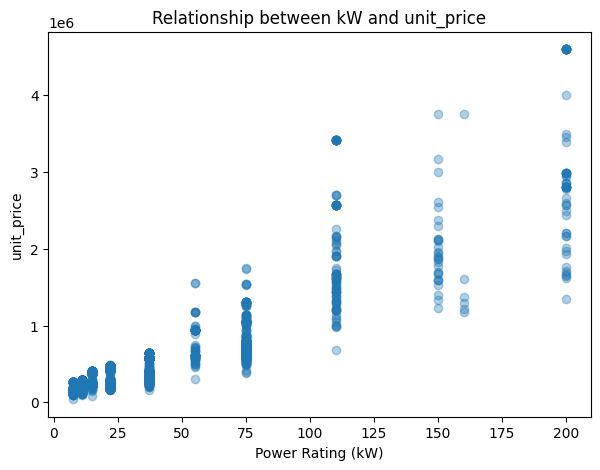

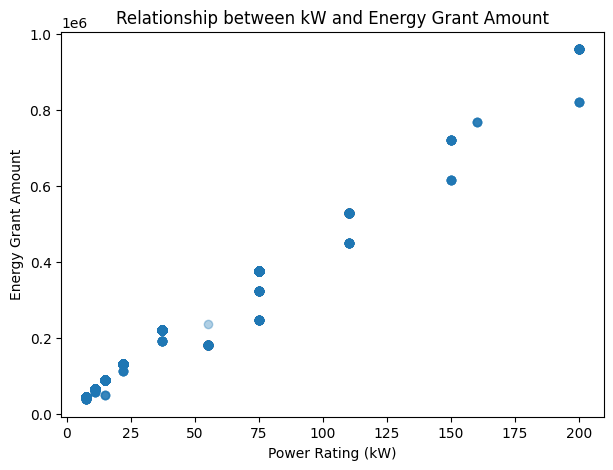

In [28]:
# Scatter: kw vs unit_price
plot_df = df.dropna(subset=['kw', 'unit_price'])
plt.figure(figsize=(7,5))
plt.scatter(plot_df['kw'], plot_df['unit_price'], alpha=0.35)
plt.xlabel('Power Rating (kW)')
plt.ylabel('unit_price')
plt.title('Relationship between kW and unit_price')
plt.show()

# Scatter: kw vs Energy Grant Amount
plot_df = df.dropna(subset=['kw', 'energy_grant_amount'])
plt.figure(figsize=(7,5))
plt.scatter(plot_df['kw'], plot_df['energy_grant_amount'], alpha=0.35)
plt.xlabel('Power Rating (kW)')
plt.ylabel('Energy Grant Amount')
plt.title('Relationship between kW and Energy Grant Amount')
plt.show()

## 7. Add attributes from Gross Margin Rate formula

Gross Margin Rate formula:

\[
	ext{GMR} =
rac{	ext{Sales Revenue} - 	ext{COGS}}{	ext{Sales Revenue}}
\]

Kalau `Subtotal Price` dianggap sebagai Sales Revenue, maka bisa dibuat atribut turunan:

\[
	ext{Gross Profit Amount} = 	ext{Revenue} 	imes 	ext{GMR}
\]

\[
	ext{Estimated COGS} = 	ext{Revenue} 	imes (1 - 	ext{GMR})
\]

Ini bukan data cost asli, tapi **estimated cost based on the margin formula**.

In [29]:
df['is_success'] = (df['convert_to_order'] == 0).astype(int)  # helper only; original label still unchanged

df['gross_profit_amount'] = df['subtotal_price'] * df['gross_margin_rate']
df['estimated_cogs'] = df['subtotal_price'] * (1 - df['gross_margin_rate'])
df['unit_gross_profit'] = df['unit_price'] * df['gross_margin_rate']
df['unit_estimated_cogs'] = df['unit_price'] * (1 - df['gross_margin_rate'])

# grant features
# customer-effective quoted cost after grant, assuming grant reduces customer effective cost
# Use max denominator guard for ratio calculations
EPS = 1e-9
df['effective_subtotal_after_grant'] = df['subtotal_price'] - df['energy_grant_amount'].fillna(0)
df['grant_to_subtotal_ratio'] = df['energy_grant_amount'] / (df['subtotal_price'] + EPS)
df['grant_to_unit_price_ratio'] = df['energy_grant_amount'] / (df['unit_price'] + EPS)

df[[
    'quote_id','subtotal_price','gross_margin_rate','gross_profit_amount',
    'estimated_cogs','energy_grant_amount','effective_subtotal_after_grant'
]].head()

,quote_id,subtotal_price,gross_margin_rate,gross_profit_amount,estimated_cogs,energy_grant_amount,effective_subtotal_after_grant
0,Q-00114,"136,000.0000",0.0712,"9,683.2000","126,316.8000",66000,"70,000.0000"
1,Q-00119,"580,000.0000",0.3079,"178,582.0000","401,418.0000",222000,"358,000.0000"
2,Q-00161,"2,379,000.0000",0.4224,"1,004,889.6000","1,374,110.4000",720000,"1,659,000.0000"
3,Q-00214,"300,000.0000",0.6787,"203,610.0000","96,390.0000",132000,"168,000.0000"
4,Q-00517,"228,964.0000",0.2949,"67,521.4836","161,442.5164",132000,"96,964.0000"


## 8. Rate GMR terhadap success rate

Karena `0 = Success`, success rate dihitung sebagai proporsi row dengan `convert_to_order == 0`.

Di sini kita binning GMR untuk melihat margin range mana yang cenderung lebih sering convert.

In [30]:
# Create GMR bins by quantile, safer if distribution is skewed
# duplicates='drop' handles repeated values
valid_gmr = df.dropna(subset=['gross_margin_rate']).copy()
valid_gmr['gmr_bin'] = pd.qcut(valid_gmr['gross_margin_rate'], q=10, duplicates='drop')

gmr_success = valid_gmr.groupby('gmr_bin', observed=True).agg(
    n=('quote_id','count'),
    gmr_min=('gross_margin_rate','min'),
    gmr_max=('gross_margin_rate','max'),
    gmr_mean=('gross_margin_rate','mean'),
    success_rate=('is_success','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_grant=('energy_grant_amount','mean')
).reset_index()

gmr_success

,gmr_bin,n,gmr_min,gmr_max,gmr_mean,success_rate,avg_unit_price,avg_grant
0,"(-1.3239999999999998, 0.118]",513,-1.3226,0.1182,0.0606,0.5283,"229,039.0132","107,082.6901"
1,"(0.118, 0.205]",487,0.1187,0.2049,0.1708,0.3101,"261,170.7747","113,358.8090"
2,"(0.205, 0.291]",499,0.2051,0.2912,0.2489,0.5471,"390,109.8271","193,968.2565"
3,"(0.291, 0.352]",501,0.2915,0.3518,0.3229,0.3912,"488,039.1017","238,137.7246"
4,"(0.352, 0.398]",497,0.3538,0.3979,0.3804,0.2133,"420,627.5154","197,228.4105"
5,"(0.398, 0.426]",499,0.3980,0.4257,0.4085,0.1222,"369,666.3639","174,027.2946"
6,"(0.426, 0.452]",501,0.4259,0.4525,0.4393,0.1178,"372,056.7687","189,904.0319"
7,"(0.452, 0.498]",501,0.4531,0.4983,0.4747,0.1657,"423,470.1122","197,942.9142"
8,"(0.498, 0.619]",535,0.4991,0.6191,0.5868,0.0953,"657,978.0810","195,558.4673"
9,"(0.619, 0.921]",461,0.6193,0.9211,0.6581,0.0347,"718,636.6108","222,887.6356"


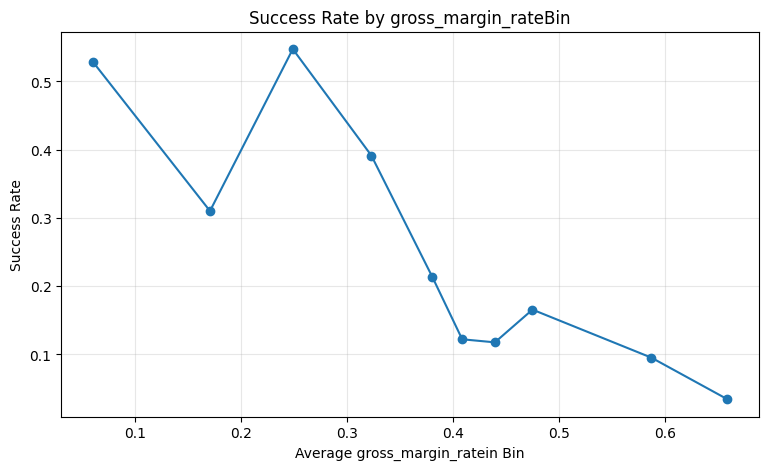

In [31]:
plt.figure(figsize=(9,5))
plt.plot(gmr_success['gmr_mean'], gmr_success['success_rate'], marker='o')
plt.xlabel('Average gross_margin_ratein Bin')
plt.ylabel('Success Rate')
plt.title('Success Rate by gross_margin_rateBin')
plt.grid(True, alpha=0.3)
plt.show()

## 9. Margin threshold: margin berapa yang convert ke kemenangan?

Cara sederhana:
- coba banyak cutoff GMR,
- hitung success rate di bawah dan di atas cutoff,
- cari range/cutoff yang menghasilkan success rate tertinggi.

Interpretasi hati-hati: ini descriptive, belum tentu causal.

In [32]:
thresholds = np.arange(-0.5, 1.01, 0.01)
rows = []
for t in thresholds:
    below = df[df['gross_margin_rate'] <= t]
    above = df[df['gross_margin_rate'] > t]
    rows.append({
        'threshold_gmr': t,
        'n_below_or_equal': len(below),
        'success_rate_below_or_equal': below['is_success'].mean() if len(below) else np.nan,
        'n_above': len(above),
        'success_rate_above': above['is_success'].mean() if len(above) else np.nan,
        'difference_below_minus_above': (below['is_success'].mean() - above['is_success'].mean()) if len(below) and len(above) else np.nan
    })

threshold_df = pd.DataFrame(rows)
threshold_df.sort_values('difference_below_minus_above', ascending=False).head(15)

,threshold_gmr,n_below_or_equal,success_rate_below_or_equal,n_above,success_rate_above,difference_below_minus_above
47,-0.0300,22,0.9545,4972,0.2506,0.7039
46,-0.0400,21,0.9524,4973,0.2508,0.7016
45,-0.0500,20,0.9500,4974,0.2509,0.6991
44,-0.0600,20,0.9500,4974,0.2509,0.6991
48,-0.0200,42,0.9286,4952,0.2480,0.6806
43,-0.0700,11,0.9091,4983,0.2523,0.6568
42,-0.0800,9,0.8889,4985,0.2526,0.6363
38,-0.1200,7,0.8571,4987,0.2529,0.6043
39,-0.1100,7,0.8571,4987,0.2529,0.6043
40,-0.1000,7,0.8571,4987,0.2529,0.6043


In [33]:
# Alternative: best GMR bin by success rate, with enough samples
MIN_N = 50
best_bins = gmr_success[gmr_success['n'] >= MIN_N].sort_values('success_rate', ascending=False)
best_bins.head(10)

,gmr_bin,n,gmr_min,gmr_max,gmr_mean,success_rate,avg_unit_price,avg_grant
2,"(0.205, 0.291]",499,0.2051,0.2912,0.2489,0.5471,"390,109.8271","193,968.2565"
0,"(-1.3239999999999998, 0.118]",513,-1.3226,0.1182,0.0606,0.5283,"229,039.0132","107,082.6901"
3,"(0.291, 0.352]",501,0.2915,0.3518,0.3229,0.3912,"488,039.1017","238,137.7246"
1,"(0.118, 0.205]",487,0.1187,0.2049,0.1708,0.3101,"261,170.7747","113,358.8090"
4,"(0.352, 0.398]",497,0.3538,0.3979,0.3804,0.2133,"420,627.5154","197,228.4105"
7,"(0.452, 0.498]",501,0.4531,0.4983,0.4747,0.1657,"423,470.1122","197,942.9142"
5,"(0.398, 0.426]",499,0.3980,0.4257,0.4085,0.1222,"369,666.3639","174,027.2946"
6,"(0.426, 0.452]",501,0.4259,0.4525,0.4393,0.1178,"372,056.7687","189,904.0319"
8,"(0.498, 0.619]",535,0.4991,0.6191,0.5868,0.0953,"657,978.0810","195,558.4673"
9,"(0.619, 0.921]",461,0.6193,0.9211,0.6581,0.0347,"718,636.6108","222,887.6356"


## 10. Energy grant amount vs margin / estimated cost / competitor price

Pertanyaan yang bisa dijawab:
- Apakah quote dengan grant lebih tinggi lebih sering success?
- Apakah grant tinggi biasanya muncul pada product/kW tertentu?
- Apakah grant bisa mengurangi effective price sehingga tetap menang walaupun quoted price tinggi?

In [34]:
# Grant bins and success rate
grant_df = df.dropna(subset=['energy_grant_amount']).copy()
grant_df['grant_bin'] = pd.qcut(grant_df['energy_grant_amount'], q=10, duplicates='drop')

grant_success = grant_df.groupby('grant_bin', observed=True).agg(
    n=('quote_id','count'),
    grant_min=('energy_grant_amount','min'),
    grant_max=('energy_grant_amount','max'),
    grant_mean=('energy_grant_amount','mean'),
    kw_mean=('kw','mean'),
    gmr_mean=('gross_margin_rate','mean'),
    unit_price_mean=('unit_price','mean'),
    success_rate=('is_success','mean')
).reset_index()

grant_success

,grant_bin,n,grant_min,grant_max,grant_mean,kw_mean,gmr_mean,unit_price_mean,success_rate
0,"(38699.999, 66000.0]",1049,38700,66000,"58,272.5834",9.7812,0.2082,"186,694.3992",0.1392
1,"(66000.0, 132000.0]",1901,90000,132000,"123,958.8006",20.6744,0.4045,"285,839.3337",0.2315
2,"(132000.0, 181500.0]",86,181500,181500,"181,500.0000",55.0000,0.3723,"778,137.5101",0.2442
3,"(181500.0, 222000.0]",1226,190920,222000,"221,569.0375",37.0000,0.4672,"398,759.0170",0.3067
4,"(222000.0, 375000.0]",531,236500,375000,"364,315.4426",74.9623,0.3731,"768,855.5217",0.3917
5,"(375000.0, 960000.0]",201,451000,960000,"673,169.1542",144.3284,0.3890,"2,268,457.8239",0.3781


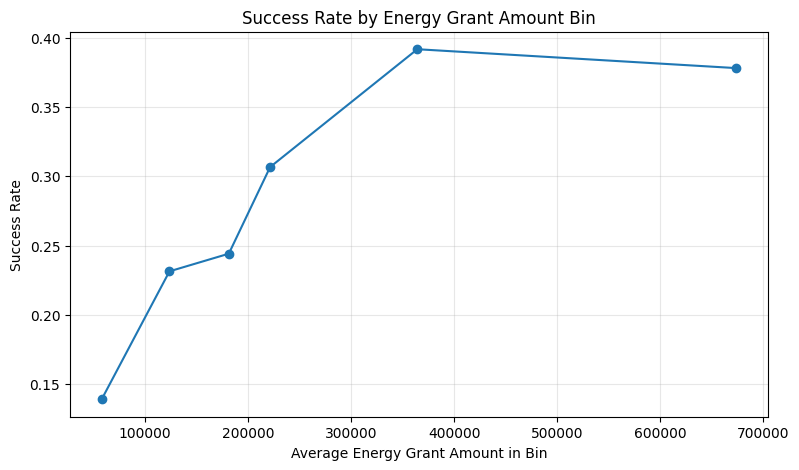

In [35]:
plt.figure(figsize=(9,5))
plt.plot(grant_success['grant_mean'], grant_success['success_rate'], marker='o')
plt.xlabel('Average Energy Grant Amount in Bin')
plt.ylabel('Success Rate')
plt.title('Success Rate by Energy Grant Amount Bin')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
# Correlation overview for numeric variables
corr_cols = [
    'kw','unit_price','qty','subtotal_price','gross_margin_rate',
    'gross_profit_amount','estimated_cogs','energy_grant_amount',
    'grant_to_subtotal_ratio','effective_subtotal_after_grant',
    'competitor_a','competitor_b','competitor_c','is_success'
]

corr = df[corr_cols].corr(numeric_only=True)
corr['is_success'].sort_values(ascending=False)

is_success                        1.0000
competitor_c                      0.3911
qty                               0.2912
estimated_cogs                    0.2237
energy_grant_amount               0.1516
kw                                0.1468
subtotal_price                    0.1076
competitor_a                      0.0940
effective_subtotal_after_grant    0.0868
grant_to_subtotal_ratio           0.0382
unit_price                       -0.0229
gross_profit_amount              -0.0619
gross_margin_rate                -0.3479
competitor_b                         NaN
Name: is_success, dtype: float64

## 11. Competitor analysis and company win distribution

Buat fitur perbandingan price dengan competitor:
- `price_gap_vs_competitor = company_unit_price - competitor_price`
- `price_gap_pct_vs_competitor = (company_unit_price - competitor_price) / competitor_price`
- negatif berarti company price lebih murah dari competitor.
- positif berarti company price lebih mahal dari competitor.

Karena competitor price mungkin per-unit benchmark, perbandingan paling aman dimulai dengan `Unit Price` vs competitor columns. Kalau ternyata competitor price adalah total quote price, perlu dikonfirmasi saat interview.

In [37]:
competitors = [col for col in ['competitor_a', 'competitor_b', 'competitor_c'] if col in df.columns]

for comp in competitors:
    df[f'price_gap_vs_{comp}'] = df['unit_price'] - df[comp]
    df[f'price_gap_pct_vs_{comp}'] = df[f'price_gap_vs_{comp}'] / (df[comp] + EPS)
    df[f'is_cheaper_than_{comp}'] = (df['unit_price'] < df[comp]).astype('Int64')
    df.loc[df[comp].isna(), f'is_cheaper_than_{comp}'] = pd.NA

# Best available competitor benchmark: minimum competitor price across available competitors.
# If the company's unit price is lower than min competitor price, it is the cheapest among available benchmarks.
if competitors:
    df['min_competitor_price'] = df[competitors].min(axis=1, skipna=True)
    df['avg_competitor_price'] = df[competitors].mean(axis=1, skipna=True)
    df['available_competitor_count'] = df[competitors].notna().sum(axis=1)
else:
    df['min_competitor_price'] = np.nan
    df['avg_competitor_price'] = np.nan
    df['available_competitor_count'] = 0

df['price_gap_vs_min_competitor'] = df['unit_price'] - df['min_competitor_price']
df['price_gap_pct_vs_min_competitor'] = df['price_gap_vs_min_competitor'] / (df['min_competitor_price'] + EPS)
df['is_cheaper_than_min_competitor'] = (df['unit_price'] < df['min_competitor_price']).astype('Int64')
df.loc[df['min_competitor_price'].isna(), 'is_cheaper_than_min_competitor'] = pd.NA

# Effective price after grant compared with competitor benchmark
df['effective_unit_price_after_grant'] = (
    df['subtotal_price'] - df['energy_grant_amount'].fillna(0)
) / df['qty'].replace(0, np.nan)

df['effective_gap_pct_vs_min_competitor'] = (
    df['effective_unit_price_after_grant'] - df['min_competitor_price']
) / (df['min_competitor_price'] + EPS)

show_cols = [
    'quote_id', 'product', 'unit_price'
] + competitors + [
    'min_competitor_price', 'price_gap_pct_vs_min_competitor',
    'effective_unit_price_after_grant', 'effective_gap_pct_vs_min_competitor',
    'is_success'
]

df[show_cols].head()


,quote_id,product,unit_price,competitor_a,competitor_b,competitor_c,min_competitor_price,price_gap_pct_vs_min_competitor,effective_unit_price_after_grant,effective_gap_pct_vs_min_competitor,is_success
0,Q-00114,W,"136,000.0000",NaN,NaN,NaN,NaN,NaN,"70,000.0000",NaN,1
1,Q-00119,H1,"290,000.0000","360,000.0000",NaN,NaN,"360,000.0000",-0.1944,"179,000.0000",-0.5028,1
2,Q-00161,Y,"2,379,000.0000",NaN,NaN,NaN,NaN,NaN,"1,659,000.0000",NaN,0
3,Q-00214,I1,"300,000.0000","240,000.0000",NaN,NaN,"240,000.0000",0.2500,"168,000.0000",-0.3000,1
4,Q-00517,I1,"228,964.0000","240,000.0000",NaN,NaN,"240,000.0000",-0.0460,"96,964.0000",-0.5960,1


In [38]:
# General win distribution: success rate by price competitiveness group
comp_df = df[df['available_competitor_count'] > 0].copy()

# Price gap group: cheaper, similar, more expensive.
# Similar means within +/- 5% of cheapest competitor price.
if len(comp_df) > 0:
    conditions = [
        comp_df['price_gap_pct_vs_min_competitor'] < -0.05,
        comp_df['price_gap_pct_vs_min_competitor'].between(-0.05, 0.05, inclusive='both'),
        comp_df['price_gap_pct_vs_min_competitor'] > 0.05,
    ]
    choices = ['Company >5% cheaper', 'Similar price ±5%', 'Company >5% more expensive']
    comp_df['price_position_vs_min_competitor'] = np.select(conditions, choices, default='Unknown')

    price_position_summary = comp_df.groupby('price_position_vs_min_competitor').agg(
        n=('quote_id','count'),
        success_rate=('is_success','mean'),
        avg_gmr=('gross_margin_rate','mean'),
        avg_grant=('energy_grant_amount','mean'),
        avg_kw=('kw','mean'),
        avg_price_gap_pct=('price_gap_pct_vs_min_competitor','mean')
    ).sort_values('success_rate', ascending=False)

    display(price_position_summary)
else:
    print("No competitor price data is available for this summary.")


,n,success_rate,avg_gmr,avg_grant,avg_kw,avg_price_gap_pct
price_position_vs_min_competitor,,,,,,
Company >5% cheaper,874,0.7941,0.2541,"263,061.2128",49.9073,-0.1935
Similar price ±5%,651,0.2304,0.4342,"239,391.7051",42.7227,0.0068
Company >5% more expensive,2638,0.0967,0.4400,"159,676.8764",28.4640,0.4820


In [39]:
# In what sector/product does the company win?
product_win_summary = df.groupby('product').agg(
    n=('quote_id','count'),
    success_count=('is_success','sum'),
    success_rate=('is_success','mean'),
    avg_kw=('kw','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_gmr=('gross_margin_rate','mean'),
    avg_grant=('energy_grant_amount','mean'),
    avg_competitor_count=('available_competitor_count','mean'),
    avg_gap_pct_vs_min_comp=('price_gap_pct_vs_min_competitor','mean')
).sort_values(['success_rate','n'], ascending=[False, False])

product_win_summary

,n,success_count,success_rate,avg_kw,avg_unit_price,avg_gmr,avg_grant,avg_competitor_count,avg_gap_pct_vs_min_comp
product,,,,,,,,,
G,7,7,1.0000,150.0000,"1,522,499.8800",0.2226,"615,000.0000",0.0000,NaN
C1,5,5,1.0000,160.0000,"1,331,799.7480",0.2777,"768,000.0000",1.0000,-0.3658
G1,1,1,1.0000,200.0000,"2,806,000.0000",0.4272,"960,000.0000",1.0000,0.4030
L,1,1,1.0000,55.0000,"300,600.0000",0.0352,"236,500.0000",0.0000,NaN
I,7,5,0.7143,200.0000,"1,868,206.4571",0.2420,"820,000.0000",0.0000,NaN
N,10,7,0.7000,75.0000,"740,296.1600",0.3219,"322,500.0000",0.0000,NaN
V,6,4,0.6667,110.0000,"1,891,723.3333",0.4356,"528,000.0000",1.0000,0.0062
C,10,6,0.6000,110.0000,"1,517,406.1500",0.2452,"451,000.0000",0.0000,NaN
Q1,10,6,0.6000,75.0000,"1,033,067.3270",0.2912,"247,500.0000",0.0000,NaN


In [40]:
# Win characteristics: compare success vs fail
win_fail_summary = df.groupby('convert_to_order').agg(
    n=('quote_id','count'),
    success_rate=('is_success','mean'),
    avg_kw=('kw','mean'),
    avg_unit_price=('unit_price','mean'),
    avg_subtotal=('subtotal_price','mean'),
    avg_gmr=('gross_margin_rate','mean'),
    avg_gross_profit=('gross_profit_amount','mean'),
    avg_estimated_cogs=('estimated_cogs','mean'),
    avg_grant=('energy_grant_amount','mean'),
    avg_grant_to_subtotal=('grant_to_subtotal_ratio','mean'),
    avg_gap_pct_vs_min_comp=('price_gap_pct_vs_min_competitor','mean'),
    avg_effective_gap_pct_vs_min_comp=('effective_gap_pct_vs_min_competitor','mean')
)

win_fail_summary.index = win_fail_summary.index.map({0: 'Success (0)', 1: 'Fail (1)'})
win_fail_summary

,n,success_rate,avg_kw,avg_unit_price,avg_subtotal,avg_gmr,avg_gross_profit,avg_estimated_cogs,avg_grant,avg_grant_to_subtotal,avg_gap_pct_vs_min_comp,avg_effective_gap_pct_vs_min_comp
convert_to_order,,,,,,,,,,,,
Success (0),1267,1.0000,41.4313,"414,020.7409","615,204.6327",0.2692,"173,411.6729","441,792.9598","219,399.1002","331,491,712,707.6602",-0.0534,-0.5082
Fail (1),3727,0.0000,31.1178,"438,604.6163","463,835.1275",0.4098,"215,804.5757","248,030.5518","170,326.2946",0.4089,0.3803,-0.1582


## 12. Possible analysis list and how to do it

This table is for report/interview planning.

In [41]:
analysis_plan = pd.DataFrame([
    {
        'Question': 'Is Subtotal Price formula correct?',
        'Method': 'Check Subtotal Price = Unit Price × Qty; report mismatch count and max difference.',
        'Output': 'Data quality table; suspicious rows if mismatch exists.'
    },
    {
        'Question': 'Are identifiers unique?',
        'Method': 'nunique and duplicated check on Quote ID.',
        'Output': 'Unique ID count, duplicate row list if any.'
    },
    {
        'Question': 'How does gross margin relate to success?',
        'Method': 'Create GMR bins and calculate success rate for each bin; test thresholds.',
        'Output': 'Success rate by GMR bin and possible margin range.'
    },
    {
        'Question': 'Can GMR formula create new features?',
        'Method': 'Use Revenue × GMR for gross profit amount and Revenue × (1-GMR) for estimated COGS.',
        'Output': 'Gross profit amount, estimated COGS, unit gross profit, unit estimated COGS.'
    },
    {
        'Question': 'Does energy grant help conversion?',
        'Method': 'Bin grant amount; compare success rate and control by product/kW if possible.',
        'Output': 'Success rate by grant bin; grant-to-subtotal ratio.'
    },
    {
        'Question': 'Does grant compensate for higher price?',
        'Method': 'Calculate effective price after grant and compare to competitor prices.',
        'Output': 'Effective price gap vs competitor and success rate.'
    },
    {
        'Question': 'How competitive is company price?',
        'Method': 'Compare Unit Price vs Competitor A/B/C; calculate price gap percentage.',
        'Output': 'Company cheaper/similar/more expensive groups and success rate.'
    },
    {
        'Question': 'Where does company win?',
        'Method': 'Group by Product and price position; compare success rate, margin, grant, kW.',
        'Output': 'Product-level win profile.'
    },
    {
        'Question': 'What makes successful quotes stand out?',
        'Method': 'Compare means/medians between Success (0) and Fail (1).',
        'Output': 'Win vs fail profile table.'
    },
    {
        'Question': 'Can we build a simple prediction model?',
        'Method': 'Optional logistic regression / decision tree using engineered features.',
        'Output': 'Feature importance or coefficient direction, not just accuracy.'
    },
])

analysis_plan

,Question,Method,Output
0,Is Subtotal Price formula correct?,Check Subtotal Price = Unit Price × Qty; repor...,Data quality table; suspicious rows if mismatc...
1,Are identifiers unique?,nunique and duplicated check on Quote ID.,"Unique ID count, duplicate row list if any."
2,How does gross margin relate to success?,Create GMR bins and calculate success rate for...,Success rate by GMR bin and possible margin ra...
3,Can GMR formula create new features?,Use Revenue × GMR for gross profit amount and ...,"Gross profit amount, estimated COGS, unit gros..."
4,Does energy grant help conversion?,Bin grant amount; compare success rate and con...,Success rate by grant bin; grant-to-subtotal r...
5,Does grant compensate for higher price?,Calculate effective price after grant and comp...,Effective price gap vs competitor and success ...
6,How competitive is company price?,Compare Unit Price vs Competitor A/B/C; calcul...,Company cheaper/similar/more expensive groups ...
7,Where does company win?,Group by Product and price position; compare s...,Product-level win profile.
8,What makes successful quotes stand out?,Compare means/medians between Success (0) and ...,Win vs fail profile table.
9,Can we build a simple prediction model?,Optional logistic regression / decision tree u...,"Feature importance or coefficient direction, n..."


## 13. Optional simple model for interpretation

This is not required for the first exploration, but useful if you want to identify important predictors. The model predicts `is_success`, while original outcome label is preserved.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Use only columns available in the dataset.
candidate_features = [
    'product', 'kw', 'unit_price', 'qty', 'subtotal_price',
    'gross_margin_rate', 'energy_grant_amount', 'grant_to_subtotal_ratio',
    'avg_price_gap_pct_vs_competitors', 'available_competitor_count'
]
features = [col for col in candidate_features if col in df.columns]

model_df = df[features + ['is_success']].dropna().copy()

X = model_df[features]
y = model_df['is_success']

cat_features = [col for col in ['product'] if col in X.columns]
num_features = [col for col in features if col not in cat_features]

# sklearn changed OneHotEncoder argument from sparse to sparse_output.
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer([
    ('cat', encoder, cat_features),
    ('num', StandardScaler(), num_features)
])

clf = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

if y.nunique() < 2 or len(model_df) < 20:
    print("Not enough usable rows/classes for logistic regression.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:,1]

    print(classification_report(y_test, pred))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, pred))
    print('ROC AUC:', roc_auc_score(y_test, proba))


              precision    recall  f1-score   support

           0       0.86      0.97      0.91       932
           1       0.86      0.55      0.67       317

    accuracy                           0.86      1249
   macro avg       0.86      0.76      0.79      1249
weighted avg       0.86      0.86      0.85      1249

Confusion matrix:
[[904  28]
 [143 174]]
ROC AUC: 0.8655836639092348


In [43]:
# Logistic regression coefficients for interpretation
if 'clf' in globals() and hasattr(clf.named_steps['model'], 'coef_'):
    pre = clf.named_steps['preprocess']
    model = clf.named_steps['model']

    feature_names = []

    if cat_features:
        feature_names.extend(
            pre.named_transformers_['cat'].get_feature_names_out(cat_features)
        )
    feature_names.extend(num_features)

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': model.coef_[0]
    }).sort_values('coefficient', ascending=False)

    display(coef_df)
else:
    print("Run the previous model cell first, or check if the model had enough data.")


,feature,coefficient
32,product_Q1,1.4449
42,kw,1.4063
36,product_U,1.3712
37,product_V,1.1369
15,product_H1,1.0918
27,product_O,1.0386
25,product_N,0.8724
44,qty,0.8552
22,product_L1,0.8099
8,product_E,0.7839


## 14. Save engineered dataset and key summary tables

This creates Excel outputs from the notebook analysis.

In [44]:
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# List candidate variables that may exist in the notebook
candidate_outputs = {
    'engineered_data': 'df',
    'raw_data': 'df_raw',
    'subtotal_check': 'subtotal_check',
    'nunique_summary': 'nunique_summary',
    'duplicate_quote_summary': 'duplicated_quote_positions',
    'quote_variation': 'quote_variation',
    'product_success': 'product_success',
    'margin_bins': 'margin_bins',
    'competitor_summary': 'competitor_summary',
    'energy_grant_summary': 'energy_grant_summary',
    'quote_level': 'quote_level',
    'revision_summary': 'revision_summary',
}

saved = []
skipped = []

for file_name, var_name in candidate_outputs.items():
    if var_name in globals():
        obj = globals()[var_name]

        if isinstance(obj, pd.DataFrame):
            obj.to_csv(OUTPUT_DIR / f'{file_name}.csv', index=False)
            saved.append(f'{file_name}.csv')
        elif isinstance(obj, pd.Series):
            obj.to_frame().to_csv(OUTPUT_DIR / f'{file_name}.csv')
            saved.append(f'{file_name}.csv')
        else:
            skipped.append((file_name, var_name, type(obj).__name__, 'not DataFrame/Series'))
    else:
        skipped.append((file_name, var_name, None, 'variable not found'))

print("Saved files:")
for f in saved:
    print("-", f)

print("\nSkipped variables:")
for file_name, var_name, obj_type, reason in skipped:
    print(f"- {file_name}: variable `{var_name}` skipped because {reason}")

Saved files:
- engineered_data.csv
- raw_data.csv

Skipped variables:
- subtotal_check: variable `subtotal_check` skipped because variable not found
- nunique_summary: variable `nunique_summary` skipped because variable not found
- duplicate_quote_summary: variable `duplicated_quote_positions` skipped because variable not found
- quote_variation: variable `quote_variation` skipped because variable not found
- product_success: variable `product_success` skipped because variable not found
- margin_bins: variable `margin_bins` skipped because variable not found
- competitor_summary: variable `competitor_summary` skipped because variable not found
- energy_grant_summary: variable `energy_grant_summary` skipped because variable not found
- quote_level: variable `quote_level` skipped because variable not found
- revision_summary: variable `revision_summary` skipped because variable not found


# End